[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/4_IMDB_Movie_Reviews_text_data.ipynb)

> ### 📖 Self-study notebook - no lecture video for this one
>
> Work through it on your own. Doing text *properly* means embeddings and sequence models, and those are Modules 4 and 5 - but you can get about **88%** on movie reviews right now, with the same dense-network recipe you already know, by throwing away word order entirely.
>
> Three things to watch for: text becoming 10,000 yes/no columns, the model **overfitting in front of you** around epoch 3-4, and the order-blindness demo in the middle. Bring questions to office hours!

# Classifying movie reviews: a binary classification example
-------------------------
**Dr. Dave Wanik**

This notebook contains the code samples found in Chapter 3, Section 5 of [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python?a_aid=keras&a_bid=76564dff). Note that the original text features far more content, in particular further explanations and figures: in this notebook, you will only find source code and related comments.

----


Two-class classification, or binary classification, may be the most widely applied kind of machine learning problem. In this example, we
will learn to classify movie reviews into "positive" reviews and "negative" reviews, just based on the text content of the reviews.

## The IMDB dataset


We'll be working with "IMDB dataset", a set of 50,000 highly-polarized reviews from the Internet Movie Database. They are split into 25,000
reviews for training and 25,000 reviews for testing, each set consisting in 50% negative and 50% positive reviews.

Why do we have these two separate training and test sets? You should never test a machine learning model on the same data that you used to
train it! Just because a model performs well on its training data doesn't mean that it will perform well on data it has never seen, and
what you actually care about is your model's performance on new data (since you already know the labels of your training data -- obviously
you don't need your model to predict those). For instance, it is possible that your model could end up merely _memorizing_ a mapping between
your training samples and their targets -- which would be completely useless for the task of predicting targets for data never seen before.
We will go over this point in much more detail in the next chapter.

Just like the MNIST dataset, the IMDB dataset comes packaged with Keras. It has already been preprocessed: the reviews (sequences of words)
have been turned into sequences of integers, where each integer stands for a specific word in a dictionary.

The following code will load the dataset (when you run it for the first time, about 80MB of data will be downloaded to your machine):

In [1]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000) # we specify how many common words to keep!


The argument `num_words=10000` means that we will only keep the top 10,000 most frequently occurring words in the training data. Rare words
will be discarded. This allows us to work with vector data of manageable size.

The variables `train_data` and `test_data` are lists of reviews, each review being a list of word indices (encoding a sequence of words).
`train_labels` and `test_labels` are lists of 0s and 1s, where 0 stands for "negative" and 1 stands for "positive":

In [2]:
print(train_data[0])
print(len(train_data[0])) # 218 words in the first sample

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
218


In [3]:
train_labels[0] # 1 means a positive movie review!

np.int64(1)

Since we restricted ourselves to the top 10,000 most frequent words, no word index will exceed 10,000:

In [4]:
max([max(sequence) for sequence in train_data])

9999

For kicks, here's how you can quickly decode one of these reviews back to English words:

In [5]:
# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()
# We reverse it, mapping integer indices to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
# We decode the review; note that our indices were offset by 3
# because 0, 1 and 2 are reserved indices for "padding", "start of sequence", and "unknown".
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])

In [6]:
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

## Look at the data before you model it

Same habit as always - only now a "row" is a movie review.

In [7]:
import numpy as np

def decode(seq):
    """integers -> English (indices are offset by 3 for padding/start/unknown)"""
    return ' '.join(reverse_word_index.get(i - 3, '?') for i in seq)

labels = np.array(train_labels)

print('=== A POSITIVE REVIEW ===')
print(' '.join(decode(train_data[np.where(labels == 1)[0][0]]).split()[:65]), '...')
print()
print('=== A NEGATIVE REVIEW ===')
print(' '.join(decode(train_data[np.where(labels == 0)[0][0]]).split()[:65]), '...')

=== A POSITIVE REVIEW ===
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the ...

=== A NEGATIVE REVIEW ===
? big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end ...


In [8]:
# how balanced is it? (this is our baseline, same question as always)
counts = np.bincount(labels)
print('negative:', counts[0])
print('positive:', counts[1])
print('baseline (always guess the majority class): %.1f%%' % (100 * counts.max() / counts.sum()))

negative: 12500
positive: 12500
baseline (always guess the majority class): 50.0%


shortest: 11 | median: 178 | longest: 2494 words


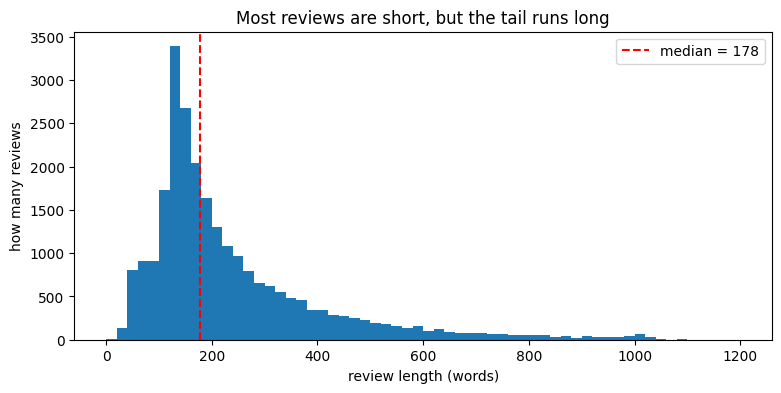

In [9]:
# how long are these reviews?
import matplotlib.pyplot as plt
lengths = np.array([len(s) for s in train_data])
print('shortest: %d | median: %d | longest: %d words' % (lengths.min(), np.median(lengths), lengths.max()))

plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=60, range=(0, 1200))
plt.axvline(np.median(lengths), color='red', linestyle='--', label='median = %d' % np.median(lengths))
plt.xlabel('review length (words)'); plt.ylabel('how many reviews')
plt.title('Most reviews are short, but the tail runs long')
plt.legend()
plt.show()

In [10]:
# which words show up most?
from collections import Counter
c = Counter(i for seq in train_data for i in seq)
for idx, n in c.most_common(15):
    print('%-12s %d' % (reverse_word_index.get(idx - 3, '?'), n))

?            341611
the          336148
and          164097
a            163040
of           145847
to           135708
is           107313
br           101871
in           93934
it           79058
i            77142
this         75974
that         69787
was          48195
as           46927


💡 The classes are perfectly balanced, so the baseline here is a flat **50%** - compare that to Titanic's 62% and MNIST's 10%. Every dataset has its own floor.

And the most common words are junk - "the", "and", "a". No sentiment at all, in every single review. The network has to learn to ignore them on its own.

## Preparing the data


We cannot feed lists of integers into a neural network. We have to turn our lists into tensors. There are two ways we could do that:

* We could pad our lists so that they all have the same length, and turn them into an integer tensor of shape `(samples, word_indices)`,
then use as first layer in our network a layer capable of handling such integer tensors (the `Embedding` layer, which we will cover in
detail later in the book).
* We could **one-hot-encode** our lists to turn them into vectors of 0s and 1s. Concretely, this would mean for instance turning the sequence
`[3, 5]` into a 10,000-dimensional vector that would be all-zeros except for indices 3 and 5, which would be ones. Then we could use as
first layer in our network a `Dense` layer, capable of handling floating point vector data.

We will go with the latter solution. Let's vectorize our data, which we will do manually for maximum clarity:

In [11]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.  # set specific indices of results[i] to 1s
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)

Here's what our samples look like now:

In [12]:
print(len(x_train[0]))
print(x_train[0])
import pandas as pd
tmp = pd.DataFrame(x_train[0])
tmp[0].value_counts()

# our first movie review had 218 words, but it looks like
# there are only 120 unique words
# we have 10000 long vector for this movie review
# and it is mostly 0s (sparse!) and has a handful of 1s.

# we have done this for all movie reviews!

10000
[0. 1. 1. ... 0. 0. 0.]


0
0.0    9880
1.0     120
Name: count, dtype: int64

### What does a one-hot review look like?

10,000 yes/no answers is hard to picture, so let's fold one review into a 100x100 grid.

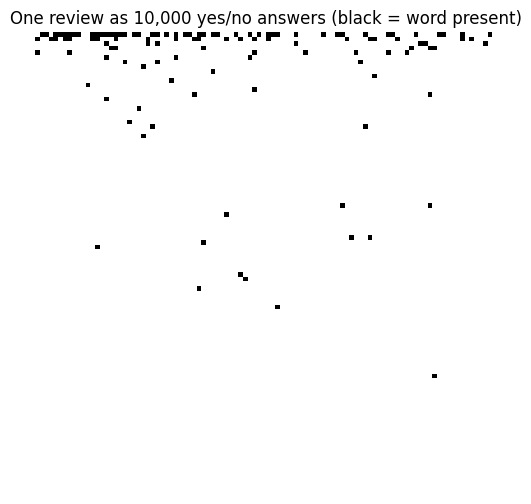

words switched ON: 120 out of 10,000
so the vector is 98.8% zeros


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(x_train[0].reshape(100, 100), cmap='binary')
plt.title('One review as 10,000 yes/no answers (black = word present)')
plt.axis('off')
plt.show()

print('words switched ON: %d out of 10,000' % int(x_train[0].sum()))
print('so the vector is %.1f%% zeros' % (100 * (1 - x_train[0].mean())))

### What this representation throws away

A bag of words records **which** words appeared, not **what order** they appeared in. Prove it to yourself:

In [14]:
def encode(text):
    """turn a plain sentence into the same 10,000-long yes/no vector"""
    idx = [word_index.get(w, 0) + 3 for w in text.lower().split()]
    return vectorize_sequences([[i for i in idx if i < 10000]])[0]

a = "the movie was not good it was boring"
b = "the movie was good not it was boring"   # same words, shuffled
c = "boring was it good not was movie the"   # same words, reversed

print('a vs b identical vectors?', np.array_equal(encode(a), encode(b)))
print('a vs c identical vectors?', np.array_equal(encode(a), encode(c)))

a vs b identical vectors? True
a vs c identical vectors? True


💡 Identical. "not good" and "good not" are the same review to this network - and it still gets ~88% right, because for sentiment, *which* words appear gets you most of the way there.

Getting the rest needs a model that can see sequence. That's Modules 4 and 5, where words become **embeddings** instead of yes/no switches. For now just carry this: **order is information, and we threw it away.**

We should also vectorize our labels, which is straightforward:

In [15]:
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [16]:
# see what we did... no need to convert to dummy labels (one hot encode)
print(y_train)

[1. 0. 0. ... 0. 1. 0.]


Now our data is ready to be fed into a neural network.

## Building our network


Our input data is simply vectors, and our labels are scalars (1s and 0s): this is the easiest setup you will ever encounter. A type of
network that performs well on such a problem would be a simple stack of fully-connected (`Dense`) layers with `relu` activations: `Dense(16,
activation='relu')`

The argument being passed to each `Dense` layer (16) is the number of "hidden units" of the layer. What's a hidden unit? It's a dimension
in the representation space of the layer. You may remember from the previous chapter that each such `Dense` layer with a `relu` activation implements
the following chain of tensor operations:

`output = relu(dot(W, input) + b)`

Having 16 hidden units means that the weight matrix `W` will have shape `(input_dimension, 16)`, i.e. the dot product with `W` will project the
input data onto a 16-dimensional representation space (and then we would add the bias vector `b` and apply the `relu` operation). You can
intuitively understand the dimensionality of your representation space as "how much freedom you are allowing the network to have when
learning internal representations". Having more hidden units (a higher-dimensional representation space) allows your network to learn more
complex representations, but it makes your network more computationally expensive and may lead to learning unwanted patterns (patterns that
will improve performance on the training data but not on the test data).

There are two key architecture decisions to be made about such stack of dense layers:

* How many layers to use.
* How many "hidden units" to chose for each layer.

In the next chapter, you will learn formal principles to guide you in making these choices.
For the time being, you will have to trust us with the following architecture choice:
two intermediate layers with 16 hidden units each,
and a third layer which will output the scalar prediction regarding the sentiment of the current review.
The intermediate layers will use `relu` as their "activation function",
and the final layer will use a sigmoid activation so as to output a probability
(a score between 0 and 1, indicating how likely the sample is to have the target "1", i.e. how likely the review is to be positive).
A `relu` (rectified linear unit) is a function meant to zero-out negative values,
while a sigmoid "squashes" arbitrary values into the `[0, 1]` interval, thus outputting something that can be interpreted as a probability.

Here's what our network looks like:

![3-layer network](https://s3.amazonaws.com/book.keras.io/img/ch3/3_layer_network.png)

And here's the Keras implementation, very similar to the MNIST example you saw previously:

In [17]:
from keras import models
from keras.layers import Dense, Dropout

model = models.Sequential()
model.add(Dense(16, activation='relu', input_shape=(10000,))) # (features,)
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.summary()

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)


Lastly, we need to pick a loss function and an optimizer. Since we are facing a binary classification problem and the output of our network
is a probability (we end our network with a single-unit layer with a sigmoid activation), is it best to use the `binary_crossentropy` loss.
It isn't the only viable choice: you could use, for instance, `mean_squared_error`. But crossentropy is usually the best choice when you
are dealing with models that output probabilities. Crossentropy is a quantity from the field of Information Theory, that measures the "distance"
between probability distributions, or in our case, between the ground-truth distribution and our predictions.

Here's the step where we configure our model with the `rmsprop` optimizer and the `binary_crossentropy` loss function. Note that we will
also monitor accuracy during training.

In [18]:
model.compile(optimizer='rmsprop', # use rmsprop or Adam
              loss='binary_crossentropy', # since we have two categories, we will use binary_crossentropy
              metrics=['accuracy'])

We are passing our optimizer, loss function and metrics as strings, which is possible because `rmsprop`, `binary_crossentropy` and
`accuracy` are packaged as part of Keras. Sometimes you may want to configure the parameters of your optimizer, or pass a custom loss
function or metric function. This former can be done by passing an optimizer class instance as the `optimizer` argument:

In [19]:
# from keras import optimizers

# model.compile(optimizer=optimizers.RMSprop(lr=0.001),
#               loss='binary_crossentropy',
#               metrics=['accuracy'])

The latter can be done by passing function objects as the `loss` or `metrics` arguments:

In [20]:
# from keras import losses
# from keras import metrics

# model.compile(optimizer=optimizers.RMSprop(lr=0.001), # just use Adam or rmsprop... no need to be fancy for now
#               loss=losses.binary_crossentropy,
#               metrics=[metrics.binary_accuracy])

## Validating our approach

In order to monitor during training the accuracy of the model on data that it has never seen before, we will create a "validation set" by
setting apart 10,000 samples from the original training data:

In [21]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

We will now train our model for 20 epochs (20 iterations over all samples in the `x_train` and `y_train` tensors), in mini-batches of 512
samples. At this same time we will monitor loss and accuracy on the 10,000 samples that we set apart. This is done by passing the
validation data as the `validation_data` argument:

In [22]:
# we can use early stopping and set epochs to some huge number if we want to

from keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_accuracy',
                   mode='max',
                   patience=10,
                   restore_best_weights = True)

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=100000,
                    batch_size=512,
                    validation_data=(x_val, y_val),
                    callbacks=[es])

Epoch 1/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.4844 - loss: 0.6954

11/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6390 - loss: 0.6486

20/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6978 - loss: 0.6019

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7335 - loss: 0.5627 - val_accuracy: 0.8389 - val_loss: 0.4291


Epoch 2/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8203 - loss: 0.4413

 8/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8447 - loss: 0.4189 

16/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8511 - loss: 0.4014

24/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8562 - loss: 0.3887

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8599 - loss: 0.3797 - val_accuracy: 0.8706 - val_loss: 0.3371


Epoch 3/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8730 - loss: 0.3232

 9/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8865 - loss: 0.3201 

17/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8934 - loss: 0.3041

25/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8937 - loss: 0.2998

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8949 - loss: 0.2971 - val_accuracy: 0.8858 - val_loss: 0.2916


Epoch 4/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9160 - loss: 0.2713

 8/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9114 - loss: 0.2600 

17/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9145 - loss: 0.2500

26/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9135 - loss: 0.2446

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9136 - loss: 0.2446 - val_accuracy: 0.8883 - val_loss: 0.2785


Epoch 5/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9375 - loss: 0.1925

 9/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9336 - loss: 0.1999 

17/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9315 - loss: 0.2032

25/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9316 - loss: 0.2009

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9312 - loss: 0.2003 - val_accuracy: 0.8866 - val_loss: 0.2781


Epoch 6/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9375 - loss: 0.1785

 9/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9460 - loss: 0.1719 

16/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9462 - loss: 0.1667

24/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9446 - loss: 0.1674

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9435 - loss: 0.1683 - val_accuracy: 0.8869 - val_loss: 0.2846


Epoch 7/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9590 - loss: 0.1437

 9/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9586 - loss: 0.1359 

17/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9514 - loss: 0.1466

25/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9512 - loss: 0.1453

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9507 - loss: 0.1451 - val_accuracy: 0.8849 - val_loss: 0.2893


Epoch 8/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9785 - loss: 0.1105

 9/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9657 - loss: 0.1216 

17/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9647 - loss: 0.1194

27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9612 - loss: 0.1232

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9605 - loss: 0.1234 - val_accuracy: 0.8842 - val_loss: 0.3164


Epoch 9/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9805 - loss: 0.0896

10/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9676 - loss: 0.1053 

19/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9683 - loss: 0.1027

29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9670 - loss: 0.1031

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9669 - loss: 0.1029 - val_accuracy: 0.8818 - val_loss: 0.3401


Epoch 10/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9648 - loss: 0.1065

10/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9766 - loss: 0.0822 

19/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9751 - loss: 0.0858

29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9722 - loss: 0.0898

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9721 - loss: 0.0897 - val_accuracy: 0.8809 - val_loss: 0.3457


Epoch 11/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9863 - loss: 0.0600

10/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9824 - loss: 0.0636 

19/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9816 - loss: 0.0666

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9801 - loss: 0.0708

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9801 - loss: 0.0708 - val_accuracy: 0.8719 - val_loss: 0.4131


Epoch 12/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9707 - loss: 0.0845

10/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9824 - loss: 0.0618 

19/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9795 - loss: 0.0683

27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9808 - loss: 0.0647

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9805 - loss: 0.0651 - val_accuracy: 0.8794 - val_loss: 0.3966


Epoch 13/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9883 - loss: 0.0466

10/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9896 - loss: 0.0449 

19/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9869 - loss: 0.0479

29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9853 - loss: 0.0510

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9853 - loss: 0.0510 - val_accuracy: 0.8749 - val_loss: 0.4280


Epoch 14/100000


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9941 - loss: 0.0334

10/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9900 - loss: 0.0404 

19/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9902 - loss: 0.0396

29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9879 - loss: 0.0426

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9879 - loss: 0.0427 - val_accuracy: 0.8782 - val_loss: 0.4608


On CPU, this will take less than two seconds per epoch -- training is over in 20 seconds. At the end of every epoch, there is a slight pause
as the model computes its loss and accuracy on the 10,000 samples of the validation data.

Note that the call to `model.fit()` returns a `History` object. This object has a member `history`, which is a dictionary containing data
about everything that happened during training. Let's take a look at it:

In [23]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

It contains 4 entries: one per metric that was being monitored, during training and during validation. Let's use Matplotlib to plot the
training and validation loss side by side, as well as the training and validation accuracy:

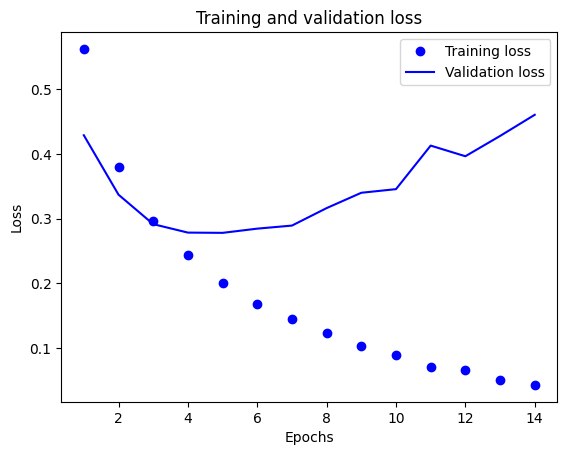

In [24]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

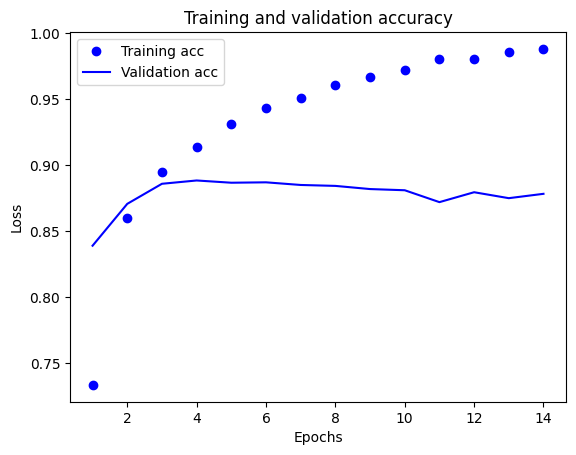

In [25]:
plt.clf()   # clear figure
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


The dots are the training loss and accuracy, while the solid lines are the validation loss and accuracy. Note that your own results may vary
slightly due to a different random initialization of your network.

As you can see, the training loss decreases with every epoch and the training accuracy increases with every epoch. That's what you would
expect when running gradient descent optimization -- the quantity you are trying to minimize should get lower with every iteration. But that
isn't the case for the validation loss and accuracy: they seem to peak at the fourth epoch. This is an example of what we were warning
against earlier: a model that performs better on the training data isn't necessarily a model that will do better on data it has never seen
before. In precise terms, what you are seeing is "overfitting": after the second epoch, we are over-optimizing on the training data, and we
ended up learning representations that are specific to the training data and do not generalize to data outside of the training set.

In this case, to prevent overfitting, we could simply stop training after three epochs. In general, there is a range of techniques you can
leverage to mitigate overfitting, which we will cover in the next chapter.

Let's train a new network from scratch for four epochs, then evaluate it on our test data:

In [26]:
model = models.Sequential()
model.add(Dense(16, activation='relu', input_shape=(10000,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4


 1/49 ━━━━━━━━━━━━━━━━━━━━ 45s 953ms/step - accuracy: 0.4785 - loss: 0.6951

10/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6641 - loss: 0.6393   

19/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7351 - loss: 0.5854

28/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7721 - loss: 0.5414

37/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7946 - loss: 0.5085

46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8098 - loss: 0.4801

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8137 - loss: 0.4721


Epoch 2/4


 1/49 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.8984 - loss: 0.2883

11/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9013 - loss: 0.2954 

19/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8996 - loss: 0.2933

28/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8995 - loss: 0.2889

37/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9010 - loss: 0.2842

47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9028 - loss: 0.2779

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9027 - loss: 0.2772


Epoch 3/4


 1/49 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9316 - loss: 0.2240

10/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9312 - loss: 0.2149 

18/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9246 - loss: 0.2180

26/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9235 - loss: 0.2168

34/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9225 - loss: 0.2161

41/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9223 - loss: 0.2157

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9215 - loss: 0.2161


Epoch 4/4


 1/49 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9316 - loss: 0.1866

10/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9367 - loss: 0.1850 

18/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9374 - loss: 0.1811

26/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9346 - loss: 0.1824

34/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9354 - loss: 0.1809

41/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9342 - loss: 0.1817

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9329 - loss: 0.1846


  1/782 ━━━━━━━━━━━━━━━━━━━━ 3:38 280ms/step - accuracy: 0.8438 - loss: 0.3106

 30/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8927 - loss: 0.2583    

 62/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8826 - loss: 0.2796

 96/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8844 - loss: 0.2771

127/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8839 - loss: 0.2835

155/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8853 - loss: 0.2823

185/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8873 - loss: 0.2784

212/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8847 - loss: 0.2841

242/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8853 - loss: 0.2820

273/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8842 - loss: 0.2849

305/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8823 - loss: 0.2872

336/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8807 - loss: 0.2921

367/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8814 - loss: 0.2925

397/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8815 - loss: 0.2921

428/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8824 - loss: 0.2888

460/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8829 - loss: 0.2891

495/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8826 - loss: 0.2908

528/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8833 - loss: 0.2895

564/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8841 - loss: 0.2885

595/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8858 - loss: 0.2857

627/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8861 - loss: 0.2850

658/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8857 - loss: 0.2852

691/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8856 - loss: 0.2847

722/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8858 - loss: 0.2850

755/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8857 - loss: 0.2844

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8858 - loss: 0.2840


In [27]:
results

[0.28396356105804443, 0.8858399987220764]

Our fairly naive approach achieves an accuracy of 88%. With state-of-the-art approaches, one should be able to get close to 95%.

## Using a trained network to generate predictions on new data

After having trained a network, you will want to use it in a practical setting. You can generate the likelihood of reviews being positive
by using the `predict` method:

In [28]:
model.predict(x_test)

  1/782 ━━━━━━━━━━━━━━━━━━━━ 1:03 81ms/step

 38/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step   

 75/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

115/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

155/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

207/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

248/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

285/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

322/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

358/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

394/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

430/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

469/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

505/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

542/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

579/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

613/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

646/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

681/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

717/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

750/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.18232797],
       [0.99968135],
       [0.85228825],
       ...,
       [0.10545092],
       [0.07621033],
       [0.4334112 ]], shape=(25000, 1), dtype=float32)

As you can see, the network is very confident for some samples (0.99 or more, or 0.01 or less) but less confident for others (0.6, 0.4).


## Hits and misses - read the ones it got wrong

With text we can just read the mistakes in plain English. Let's do that.

In [29]:
# probabilities for the whole test set
probs = model.predict(x_test, verbose=0).ravel()
pred = (probs >= 0.5).astype(int)
true = y_test.astype(int)
conf = np.where(probs >= 0.5, probs, 1 - probs)

hits = np.where(pred == true)[0]
miss = np.where(pred != true)[0]

print('hits  :', len(hits))
print('misses:', len(miss), ' out of', len(true))
print('accuracy: %.4f' % (len(hits) / len(true)))

hits  : 22146
misses: 2854  out of 25000
accuracy: 0.8858


In [30]:
def show(i, n_words=55):
    print('actually %s | model said %s (%.0f%% sure)' % (
        'POSITIVE' if true[i] else 'NEGATIVE',
        'POSITIVE' if pred[i] else 'NEGATIVE', conf[i] * 100))
    print(' '.join(decode(test_data[i]).split()[:n_words]), '...')
    print('-' * 95)

print('=== THREE IT NAILED ===\n')
for i in hits[np.argsort(-conf[hits])][:3]:
    show(i)

=== THREE IT NAILED ===

actually NEGATIVE | model said NEGATIVE (100% sure)
? the first ? 1 but here's the review of ? 2 br br contains spoilers so beware readers br br oh my oh my my my i'll start off with telling you that i had no hopes in the least bit that this movie would be good considering that ? the first movie is ...
-----------------------------------------------------------------------------------------------
actually NEGATIVE | model said NEGATIVE (100% sure)
? ? or creatures from the ? as i'm positive it's more ? known as filmed under as the title creatures from the ? appears over a moving image in the same ? type as the rest of the credits starts with five 20 something kids mike clay rogers his girlfriend margaret sharon sisters julie ...
-----------------------------------------------------------------------------------------------
actually NEGATIVE | model said NEGATIVE (100% sure)
? with this movie i was really hoping that the idea was to make up for the ? together ? 

In [31]:
print('=== THREE IT GOT CONFIDENTLY WRONG ===\n')
for i in miss[np.argsort(-conf[miss])][:3]:
    show(i)

=== THREE IT GOT CONFIDENTLY WRONG ===

actually NEGATIVE | model said POSITIVE (100% sure)
? mickey rourke ? diane lane in ? ? ? it is not like mickey rourke ever really disappeared he has had a steady string of appearances before he burst back on the scene he was memorable in domino sin city man on fire once upon a time in mexico and get carter but in ...
-----------------------------------------------------------------------------------------------
actually NEGATIVE | model said POSITIVE (100% sure)
? los angeles 1976 indie film brat john carpenter fresh out of film school and with one film his class no budget spoof of 2001 called dark star under his belt finishes a gritty ? called assault on ? 13 the story of an almost deserted police station under siege by an unseen la gang ...
-----------------------------------------------------------------------------------------------
actually POSITIVE | model said NEGATIVE (100% sure)
? 2001 a space odyssey is set in 2001 and the main charact

In [32]:
# remember those identical vectors? now watch the model predict on them
for s in (a, b, c):
    print('  %.4f   "%s"' % (model.predict(encode(s).reshape(1, -1), verbose=0)[0][0], s))

  0.2832   "the movie was not good it was boring"
  0.2832   "the movie was good not it was boring"


  0.2832   "boring was it good not was movie the"


💡 The classic miss is a review that praises a movie for four sentences and then turns on it. The model counted positive words and never saw the pivot - because it cannot see a pivot.

That is not something more layers or more dropout will fix. It is the representation, and those three identical predictions above are the proof.

## Further experiments


* We were using 2 hidden layers. Try to use 1 or 3 hidden layers and see how it affects validation and test accuracy.
* Try to use layers with more hidden units or less hidden units: 32 units, 64 units...
* Try to use the `mse` loss function instead of `binary_crossentropy`.
* Try to use the `tanh` activation (an activation that was popular in the early days of neural networks) instead of `relu`.

These experiments will help convince you that the architecture choices we have made are all fairly reasonable, although they can still be
improved!

## Conclusions


Here's what you should take away from this example:

* There's usually quite a bit of preprocessing you need to do on your raw data in order to be able to feed it -- as tensors -- into a neural
network. In the case of sequences of words, they can be encoded as binary vectors -- but there are other encoding options too.
* Stacks of `Dense` layers with `relu` activations can solve a wide range of problems (including sentiment classification), and you will
likely use them frequently.
* In a binary classification problem (two output classes), your network should end with a `Dense` layer with 1 unit and a `sigmoid` activation,
i.e. the output of your network should be a scalar between 0 and 1, encoding a probability.
* With such a scalar sigmoid output, on a binary classification problem, the loss function you should use is `binary_crossentropy`.
* The `rmsprop` optimizer is generally a good enough choice of optimizer, whatever your problem. That's one less thing for you to worry
about.
* As they get better on their training data, neural networks eventually start _overfitting_ and end up obtaining increasingly worse results on data
never-seen-before. Make sure to always monitor performance on data that is outside of the training set.
